In [1]:
import duckdb
from pathlib import Path

STORE_DIR = Path(r"C:\Users\z3553082\AppData\Local\ciccada\ami_store")
con = duckdb.connect()

## METER

In [2]:
TABLE = "ami_meter"

list_random = con.sql(f"""
    SELECT DISTINCT site_id FROM read_parquet(
        '{(STORE_DIR / TABLE).as_posix()}/dt_month=*/*.parquet', hive_partitioning=1)
    LIMIT 20
""").df()

list_random

,site_id
0,537991814
1,539303695
2,542569875
3,558001048
4,1300991928
5,1301628361
6,1303818686
7,1313111073
8,1318309420
9,1320903033


In [3]:
SITE_ID = 931508817
# SITE_ID = 1086759571

In [4]:
def read_table(table_name, site_id=SITE_ID):
    return con.sql(f"""
        SELECT * FROM read_parquet('{(STORE_DIR / table_name).as_posix()}/dt_month=*/*.parquet',
                                    hive_partitioning=1)
        WHERE site_id = {site_id}
        ORDER BY t_stamp
    """).df()

In [5]:
df_meter = read_table(TABLE)

In [6]:
# df_meter.to_csv("df_meter_example.csv", index=False)

In [7]:
from datetime import timedelta

df_meter["t_stamp"] = df_meter["t_stamp"] + timedelta(hours=10)

In [8]:
df_day_meter = df_meter[(df_meter["t_stamp"] >= "2025-02-15") & (df_meter["t_stamp"] < "2025-02-16")]

In [9]:
df_day_meter

,site_id,device_id,circuit_id,t_stamp,year,month,V,P_kw,Q_kvar,S_kva,power_factor,current_a,energy_import_kwh,energy_export_kwh,dt_month
12811,931508817,107082,515632,2025-02-15 00:00:00,2025,2,235.15,4.022980,-0.443953,4.047402,0.987968,14.9790,0.335248,0.0,2025-02
12812,931508817,107082,515632,2025-02-15 00:05:00,2025,2,237.10,2.419770,-0.458936,2.462907,0.965278,10.5920,0.201648,0.0,2025-02
12813,931508817,107082,515632,2025-02-15 00:10:00,2025,2,237.80,2.666450,-0.415710,2.698661,0.976271,13.1295,0.222204,0.0,2025-02
12814,931508817,107082,515632,2025-02-15 00:15:00,2025,2,235.85,3.870477,-0.450407,3.896595,0.986639,16.7180,0.322540,0.0,2025-02
12815,931508817,107082,515632,2025-02-15 00:20:00,2025,2,236.45,3.935300,-0.446726,3.960575,0.987278,17.1220,0.327942,0.0,2025-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13094,931508817,107082,515632,2025-02-15 23:35:00,2025,2,245.95,0.275717,-0.455760,0.532670,0.267923,2.2805,0.022976,0.0,2025-02
13095,931508817,107082,515632,2025-02-15 23:40:00,2025,2,244.55,0.666890,-0.351430,0.753820,0.782660,5.3520,0.055574,0.0,2025-02
13096,931508817,107082,515632,2025-02-15 23:45:00,2025,2,242.25,1.910053,-0.399850,1.951457,0.958017,8.1065,0.159171,0.0,2025-02
13097,931508817,107082,515632,2025-02-15 23:50:00,2025,2,240.55,1.823250,-0.409860,1.868750,0.951897,8.2810,0.151938,0.0,2025-02


In [10]:
df_day_meter['circuit_id'].unique()

array([515632])

Text(0.5, 0, 'Timestamp')

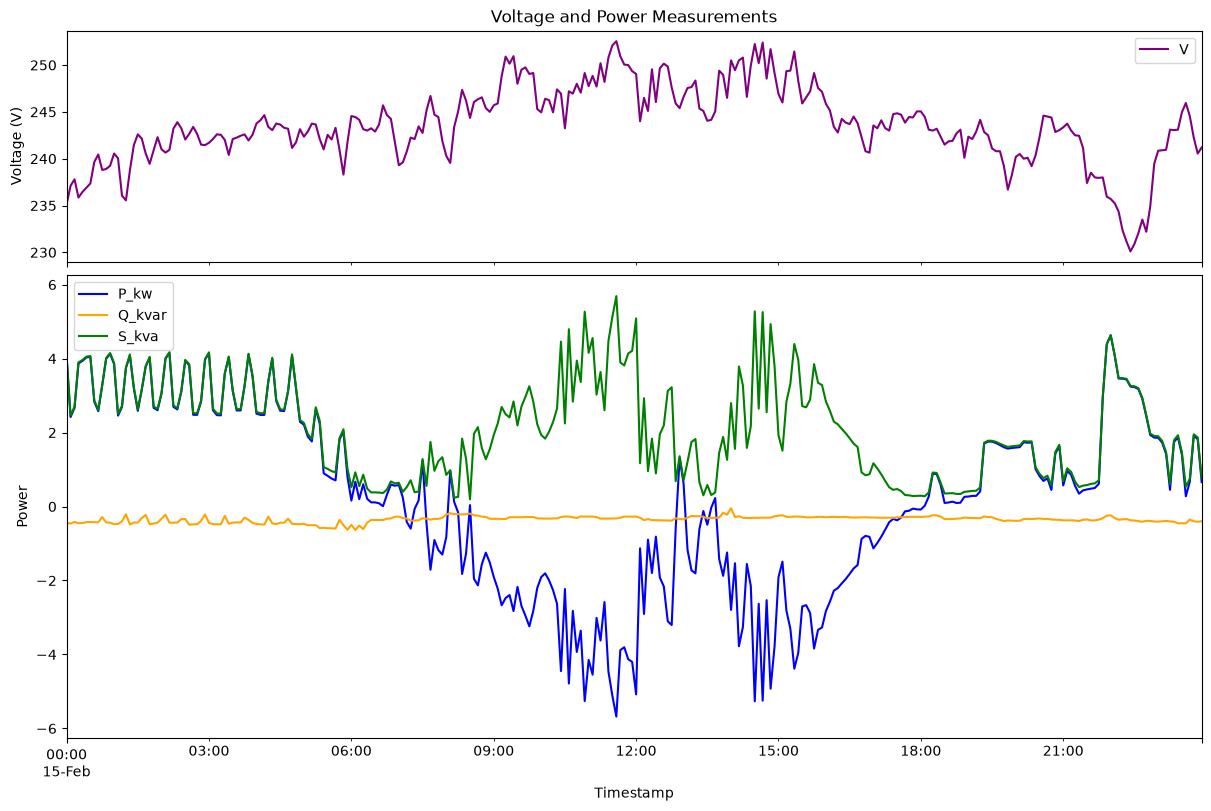

In [11]:
import matplotlib.pyplot as plt

fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

df_day_meter.plot(
    x="t_stamp",
    y="V",
    kind="line",
    ax=ax_voltage,
    color="purple",
    title="Voltage and Power Measurements",
    ylabel="Voltage (V)",
)

df_day_meter.plot(
    x="t_stamp",
    y=["P_kw", "Q_kvar", "S_kva"],
    kind="line",
    ax=ax_power,
    color=["blue", "orange", "green"],
    ylabel="Power",
)

ax_power.set_xlabel("Timestamp")

## RAW

In [12]:
df_raw = read_table("ami_raw")

In [13]:
# df_raw.to_csv("df_raw_example.csv", index=False)

In [14]:
df_raw["t_stamp"] = df_raw["t_stamp"] + timedelta(hours=10)
df_day_raw = df_raw[(df_raw["t_stamp"] >= "2025-02-15") & (df_raw["t_stamp"] < "2025-02-16")]

In [15]:
df_day_raw

,site_id,t_stamp,year,month,V_load,V_pv,P_load_kw,P_pv_kw,P_kw_norm,P_kw,Q_load_kvar,Q_pv_kvar,Q_kvar_norm,Q_kvar,S_99,ac_capacity_kw,normalization_basis,dt_month
12811,931508817,2025-02-15 00:00:00,2025,2,235.15,235.15,4.022980,-0.001017,-0.000172,4.021963,-0.443953,0.037477,0.006352,-0.406476,5.900408,6.0,s_99,2025-02
12812,931508817,2025-02-15 00:05:00,2025,2,237.10,237.20,2.419770,-0.002140,-0.000363,2.417630,-0.458936,0.038353,0.006500,-0.420583,5.900408,6.0,s_99,2025-02
12813,931508817,2025-02-15 00:10:00,2025,2,237.80,237.85,2.666450,-0.001970,-0.000334,2.664480,-0.415710,0.038617,0.006545,-0.377093,5.900408,6.0,s_99,2025-02
12814,931508817,2025-02-15 00:15:00,2025,2,235.85,235.40,3.870477,-0.001113,-0.000189,3.869363,-0.450407,0.037894,0.006422,-0.412513,5.900408,6.0,s_99,2025-02
12815,931508817,2025-02-15 00:20:00,2025,2,236.45,235.40,3.935300,-0.001087,-0.000184,3.934213,-0.446726,0.037937,0.006430,-0.408790,5.900408,6.0,s_99,2025-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13094,931508817,2025-02-15 23:35:00,2025,2,245.95,245.60,0.275717,-0.003297,-0.000559,0.272420,-0.455760,0.040916,0.006935,-0.414844,5.900408,6.0,s_99,2025-02
13095,931508817,2025-02-15 23:40:00,2025,2,244.55,244.25,0.666890,-0.003017,-0.000511,0.663873,-0.351430,0.040597,0.006880,-0.310832,5.900408,6.0,s_99,2025-02
13096,931508817,2025-02-15 23:45:00,2025,2,242.25,242.15,1.910053,-0.002083,-0.000353,1.907970,-0.399850,0.039650,0.006720,-0.360199,5.900408,6.0,s_99,2025-02
13097,931508817,2025-02-15 23:50:00,2025,2,240.55,240.20,1.823250,-0.002127,-0.000360,1.821123,-0.409860,0.039070,0.006622,-0.370790,5.900408,6.0,s_99,2025-02


In [16]:
df_day_raw["P_kw_deNorm"] = df_day_raw["P_pv_kw"] * df_day_raw["S_99"]
df_day_raw["Q_kvar_deNorm"] = df_day_raw["Q_pv_kvar"] * df_day_raw["S_99"]

Text(0.5, 0, 'Timestamp')

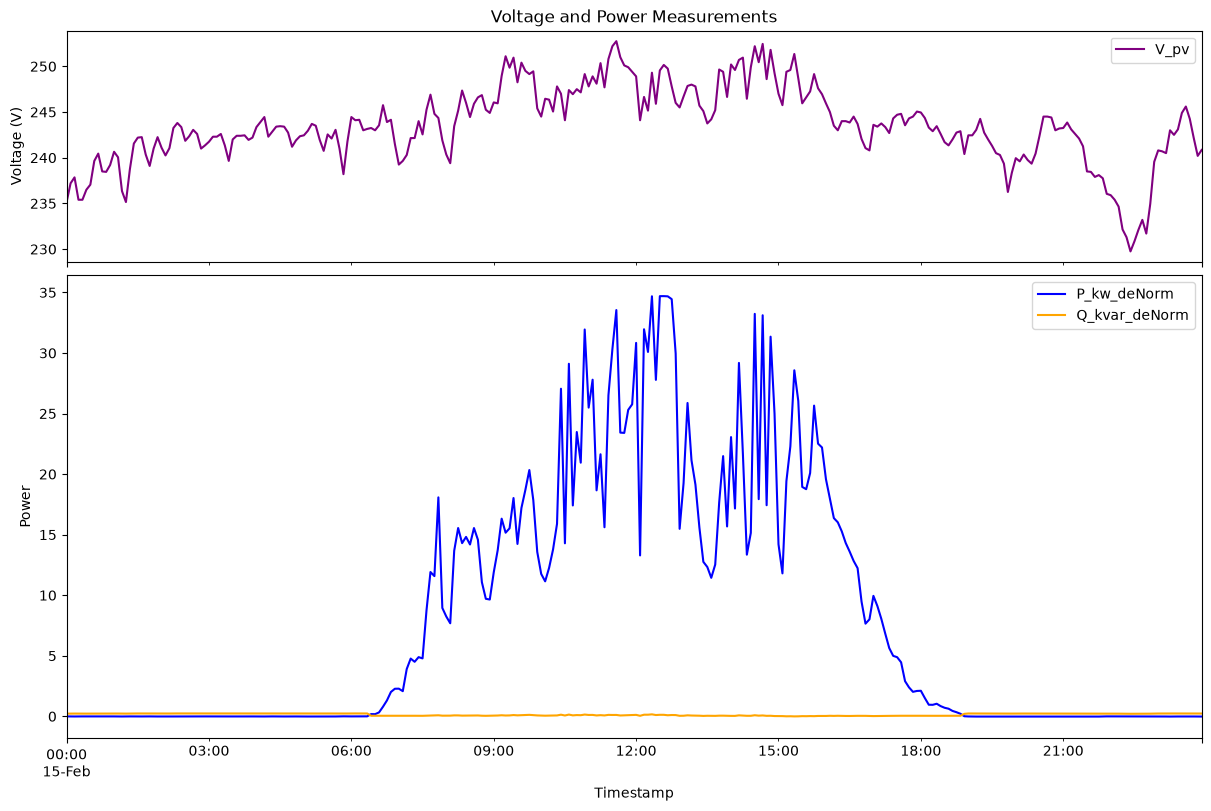

In [17]:
fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

df_day_raw.plot(
    x="t_stamp",
    y="V_pv",
    kind="line",
    ax=ax_voltage,
    color="purple",
    title="Voltage and Power Measurements",
    ylabel="Voltage (V)",
)

df_day_raw.plot(
    x="t_stamp",
    y=["P_kw_deNorm", "Q_kvar_deNorm"],
    kind="line",
    ax=ax_power,
    color=["blue", "orange", "green"],
    ylabel="Power",
)

ax_power.set_xlabel("Timestamp")

Text(0.5, 0, 'Timestamp')

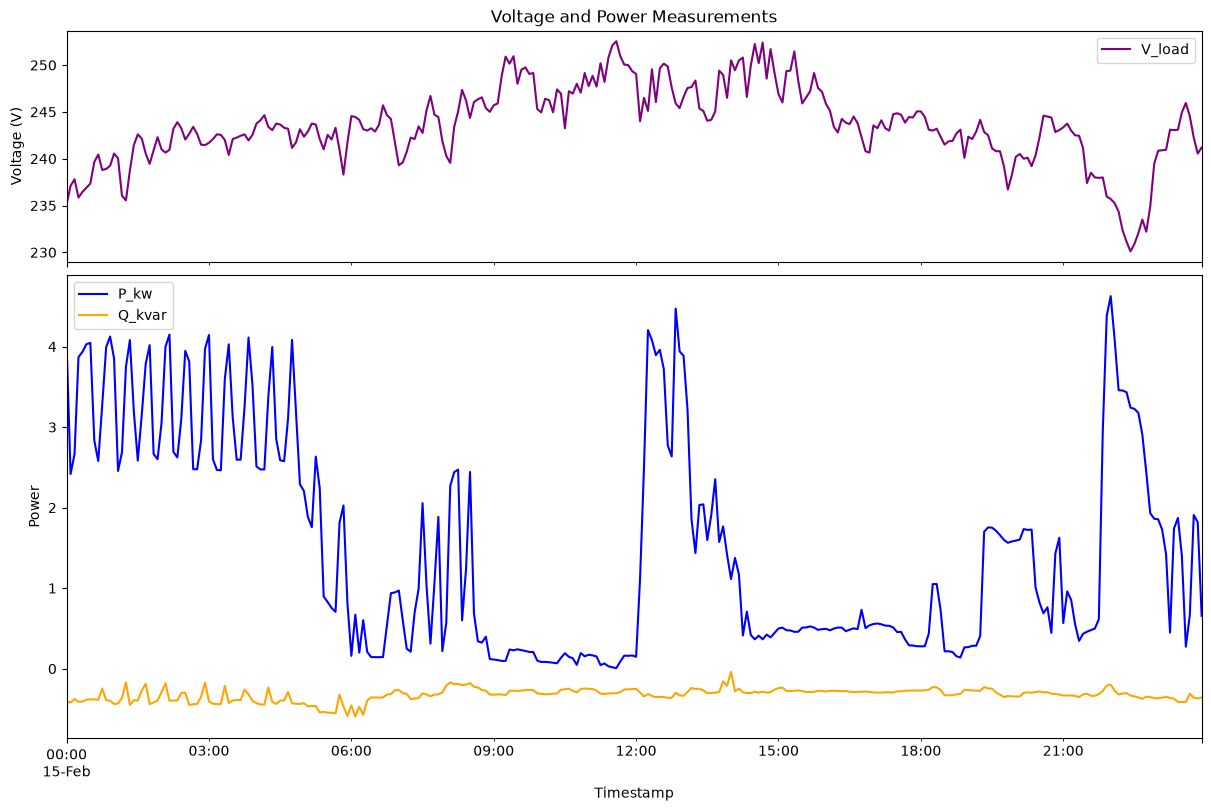

In [18]:
fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

df_day_raw.plot(
    x="t_stamp",
    y="V_load",
    kind="line",
    ax=ax_voltage,
    color="purple",
    title="Voltage and Power Measurements",
    ylabel="Voltage (V)",
)

df_day_raw.plot(
    x="t_stamp",
    y=["P_kw", "Q_kvar"],
    kind="line",
    ax=ax_power,
    color=["blue", "orange", "green"],
    ylabel="Power",
)

ax_power.set_xlabel("Timestamp")

In [19]:
df_day_raw

,site_id,t_stamp,year,month,V_load,V_pv,P_load_kw,P_pv_kw,P_kw_norm,P_kw,Q_load_kvar,Q_pv_kvar,Q_kvar_norm,Q_kvar,S_99,ac_capacity_kw,normalization_basis,dt_month,P_kw_deNorm,Q_kvar_deNorm
12811,931508817,2025-02-15 00:00:00,2025,2,235.15,235.15,4.022980,-0.001017,-0.000172,4.021963,-0.443953,0.037477,0.006352,-0.406476,5.900408,6.0,s_99,2025-02,-0.005999,0.221131
12812,931508817,2025-02-15 00:05:00,2025,2,237.10,237.20,2.419770,-0.002140,-0.000363,2.417630,-0.458936,0.038353,0.006500,-0.420583,5.900408,6.0,s_99,2025-02,-0.012627,0.226300
12813,931508817,2025-02-15 00:10:00,2025,2,237.80,237.85,2.666450,-0.001970,-0.000334,2.664480,-0.415710,0.038617,0.006545,-0.377093,5.900408,6.0,s_99,2025-02,-0.011624,0.227857
12814,931508817,2025-02-15 00:15:00,2025,2,235.85,235.40,3.870477,-0.001113,-0.000189,3.869363,-0.450407,0.037894,0.006422,-0.412513,5.900408,6.0,s_99,2025-02,-0.006569,0.223588
12815,931508817,2025-02-15 00:20:00,2025,2,236.45,235.40,3.935300,-0.001087,-0.000184,3.934213,-0.446726,0.037937,0.006430,-0.408790,5.900408,6.0,s_99,2025-02,-0.006412,0.223843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13094,931508817,2025-02-15 23:35:00,2025,2,245.95,245.60,0.275717,-0.003297,-0.000559,0.272420,-0.455760,0.040916,0.006935,-0.414844,5.900408,6.0,s_99,2025-02,-0.019452,0.241423
13095,931508817,2025-02-15 23:40:00,2025,2,244.55,244.25,0.666890,-0.003017,-0.000511,0.663873,-0.351430,0.040597,0.006880,-0.310832,5.900408,6.0,s_99,2025-02,-0.017800,0.239540
13096,931508817,2025-02-15 23:45:00,2025,2,242.25,242.15,1.910053,-0.002083,-0.000353,1.907970,-0.399850,0.039650,0.006720,-0.360199,5.900408,6.0,s_99,2025-02,-0.012292,0.233954
13097,931508817,2025-02-15 23:50:00,2025,2,240.55,240.20,1.823250,-0.002127,-0.000360,1.821123,-0.409860,0.039070,0.006622,-0.370790,5.900408,6.0,s_99,2025-02,-0.012548,0.230527


In [20]:
df_day_raw["P_house_load_kw"] = df_day_raw["P_pv_kw"] - df_day_raw["P_pv_kw_deNorm"]
df_day_raw["Q_house_load_kvar"] = df_day_raw["Q_pv_kvar"] - df_day_raw["Q_pv_kvar_deNorm"]

KeyError: 'P_pv_kw_deNorm'

In [ ]:
fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

df_day_raw.plot(
    x="t_stamp",
    y="V_load",
    kind="line",
    ax=ax_voltage,
    color="purple",
    title="Voltage and Power Measurements",
    ylabel="Voltage (V)",
)

df_day_raw.plot(
    x="t_stamp",
    y=["P_house_load_kw", "Q_house_load_kvar"],
    kind="line",
    ax=ax_power,
    color=["blue", "orange", "green"],
    ylabel="Power",
)

ax_power.set_xlabel("Timestamp")

# RAW Phase separate

In [ ]:
df_raw_phase_separate = read_table("ami_raw_phaseseparate")

In [ ]:
# df_raw_phase_separate.to_csv("df_raw_phase_separate_example.csv", index=False)

In [ ]:
df_raw_phase_separate["t_stamp"] = df_raw_phase_separate["t_stamp"] + timedelta(hours=10)
df_day_raw_phase_separate = df_raw_phase_separate[(df_raw_phase_separate["t_stamp"] >= "2025-02-15") & (df_raw_phase_separate["t_stamp"] < "2025-02-16")]

In [ ]:
df_day_raw_phase_separate

In [ ]:
fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

df_day_raw_phase_separate.plot(
    x="t_stamp",
    y="V",
    kind="line",
    ax=ax_voltage,
    color="purple",
    title="Voltage and Power Measurements",
    ylabel="Voltage (V)",
)

df_day_raw_phase_separate.plot(
    x="t_stamp",
    y=["pv_allocation_kw", "pv_reactive_allocation_kvar"],
    kind="line",
    ax=ax_power,
    color=["blue", "orange", "green"],
    ylabel="Power",
)

ax_power.set_xlabel("Timestamp")

In [ ]:
fig, (ax_voltage, ax_power) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(12, 8),
    constrained_layout=True,
    gridspec_kw={"height_ratios": [1, 2]},
)

df_day_raw_phase_separate.plot(
    x="t_stamp",
    y="V",
    kind="line",
    ax=ax_voltage,
    color="purple",
    title="Voltage and Power Measurements",
    ylabel="Voltage (V)",
)

df_day_raw_phase_separate.plot(
    x="t_stamp",
    y=["pv_allocation_kw", "pv_reactive_allocation_kvar"],
    kind="line",
    ax=ax_power,
    color=["blue", "orange", "green"],
    ylabel="Power",
)

ax_power.set_xlabel("Timestamp")

# TS RAW

In [ ]:
from pathlib import Path

import duckdb

base_path = Path(
    r"C:\Users\z3553082\AppData\Local\ciccada\ami_store\ami_extract"
)
parquet_pattern = (
    f"{base_path.as_posix()}/dt_month=*/part-load-*"
)

columns = duckdb.query(f"""
    SELECT *
    FROM read_parquet(
        '{parquet_pattern}',
        hive_partitioning = true
    )
    LIMIT 5
""").df().columns

print(columns)

In [ ]:
site_id = "360624571"
circuit_id = 515629
month = "2025-03"

In [ ]:
query = f"""
    SELECT *
    FROM read_parquet(
        '{parquet_pattern}',
        hive_partitioning = true
    )
    WHERE dt_month = '2025-07'
      AND circuit_id = 515629
    ORDER BY t_stamp
"""

july_df = duckdb.query(query).df()

print(july_df.shape)
july_df.head()

In [ ]:
duckdb.query(f"""
    SELECT DISTINCT circuit_id
    FROM read_parquet(
        '{parquet_pattern}',
        hive_partitioning = true
    )
    ORDER BY circuit_id
    LIMIT 50
""").df()

# GET PHASE COUNTED SITES

In [ ]:
import duckdb
from pathlib import Path

STORE_DIR = Path(r"C:\Users\z3553082\AppData\Local\ciccada\ami_store")
con = duckdb.connect()

load_phase_counts = con.sql(f"""
    SELECT site_id, COUNT(DISTINCT circuit_id) AS n_load_phases
    FROM read_parquet('{(STORE_DIR / "ami_meter").as_posix()}/dt_month=*/*.parquet', hive_partitioning=1)
    GROUP BY site_id
""").df()

pv_allocation = con.sql(f"""
    SELECT site_id, pv_allocation_method, COUNT(*) AS n_rows
    FROM read_parquet('{(STORE_DIR / "ami_raw_phaseseparate").as_posix()}/dt_month=*/*.parquet', hive_partitioning=1)
    GROUP BY site_id, pv_allocation_method
""").df()

# one row per site: its (only, or dominant) allocation method
site_method = (
    pv_allocation.sort_values("n_rows", ascending=False)
    .drop_duplicates("site_id")[["site_id", "pv_allocation_method"]]
)

combined = load_phase_counts.merge(site_method, on="site_id", how="left")

load3_pv3 = combined[(combined.n_load_phases == 3) & (combined.pv_allocation_method == "direct_matched_circuit")]
load1_pv_unmatched = combined[(combined.n_load_phases == 1) & (combined.pv_allocation_method == "equal_split_across_load_phases")]
load3_pv_unmatched = combined[(combined.n_load_phases == 3) & (combined.pv_allocation_method == "equal_split_across_load_phases")]

print(len(load3_pv3), len(load1_pv_unmatched), len(load3_pv_unmatched))
load3_pv3.site_id.tolist()[:10]

In [ ]:
load3_pv3